# Unstructured mesh R2S shutdown dose rate

In this example we perform a shutdown dose rate simulation using the R2S method on an unstructured mesh.

This is a very minimal example that only has a single cell and single material

First we import all the packages we will need for the simulations

In [1]:
from cad_to_dagmc import CadToDagmc
import cadquery as cq
import openmc
from matplotlib.colors import LogNorm
import openmc.deplete
from pathlib import Path

Then we sets the cross section path to the correct location in the docker image.
If you are running this outside the docker image you will have to change this path to your local cross section path.

In [2]:
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

makes a CAD geometry to use for the neutronics geometry

In [3]:
s = cq.Workplane("XY")
sPnts = [
    (2.75, 1.5),
    (2.5, 1.75),
    (2.0, 1.5),
    (1.5, 1.0),
    (1.0, 1.25),
    (0.5, 1.0),
    (0, 1.0),
]
r = s.lineTo(3.0, 0).lineTo(3.0, 1.0).spline(sPnts, includeCurrent=True).close()
result = r.extrude(0.5)


Convert the CAD geometry to a DAGMC surface mesh and MOAB volume mesh

In [4]:

my_model = CadToDagmc()

my_model.add_cadquery_object(result, material_tags=['mat1'])


# this makes the tet mesh used for the unstructured mesh tally which is overlaid on the geometry
# this also makes the surface mesh used for the material volume
# the outer surface for both mesh have the same mesh nodes, they are conformal
dagmc_filename, umesh_filename = my_model.export_dagmc_h5m_file(
    filename="dagmc.h5m",
    max_mesh_size=0.8,
    min_mesh_size=0.1,
    unstructured_volumes=[1],
    umesh_filename="umesh.vtk",
)


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 4 (Line)
Info    : [  0%] Meshing curve 6 (Line)
Info    : [  0%] Meshing curve 10 (BSpline)
Info    : [  0%] Meshing curve 9 (BSpline)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 7 (Line)
Info    : [  0%] Meshing curve 3 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 12 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 2 (Line)
Info    : Done meshing 1D (Wall 0.127128s, CPU 0.116545s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 3 (Unknown, MeshAdapt)
Info    : [  0%] Meshing surface 5 (Plane, MeshAdapt)
Info    : [  0%] Meshing surface 6 (Plane, MeshAdapt)
Info    : [  0%] Meshing surface 1 (Plane, MeshAdapt)
Info    : [  0%] Meshing surface 2 (Plane, MeshAdapt)
Info    : [  0%] Meshing surface 4 (Plane, MeshAdapt)
Info    : Done meshing 2D (Wall 0.018995s, CPU 0.023101s)
Info    : 161 nodes 3

Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 161 nodes...
Info    : Done tetrahedrizing 169 nodes (Wall 0.00486496s, CPU 0.005218s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.0175821s, CPU 0.011453s)
Info    : Found volume 1
Info    : It. 0 - 0 nodes created - worst tet radius 1.01594 (nodes removed 0 0)
Info    : 3D refinement terminated (162 nodes total):
Info    :  - 0 Delaunay cavities modified for star shapeness
Info    :  - 0 nodes could not be inserted
Info    :  - 404 tetrahedra created in 0.000661266 sec. (610949 tets/s)
Info    : 0 node relocations
Info    : Done meshing 3D (Wall 0.0503533s, CPU 0.021084s)
Info    : Optimizing mesh...
Info    : Optimizing volume 1
Info    : Optimization starts (volume = 1.88997) with worst = 0.0558498 / average = 0.707491:
Info    : 0.00 < qual

Info    : Done writing 'umesh.vtk'


Now use the two meshes in OpenMC to make the DAGMCUniverse and the UnstructuredMesh

We transport particles on the DAGMCUniverse

We will get the flux on the UnstructuredMesh tets and then activate the materials on each tet and use this information to make source terms

In [5]:
# add adding distance to avoid source being born on edge of geometry and the 2nd simulation crashing
universe = openmc.DAGMCUniverse("dagmc.h5m").bounded_universe(padding_distance=1)
my_geometry = openmc.Geometry(universe)

# the unstructured mesh to overlay on the DAGMC geometry
umesh = openmc.UnstructuredMesh("umesh.vtk", library="moab")

Make the material used for the simulation

In [6]:
my_material = openmc.Material(name='mat1', material_id=1)
my_material.add_nuclide("Fe56", 1, percent_type="ao")
my_material.set_density("g/cm3", 0.001)
my_material.depletable = True
my_materials = openmc.Materials([my_material])

Make a simple neutron source in the center of the geometry

In [7]:
# Create a DT point source
my_source = openmc.IndependentSource()
my_source.space = openmc.stats.Point(my_geometry.bounding_box.center)
my_source.angle = openmc.stats.Isotropic()
my_source.energy = openmc.stats.Discrete([14e6], [1])


Make the simulation settings for the neutron irradiation

In [8]:
my_settings = openmc.Settings()
my_settings.batches = 5
my_settings.particles = 5000
my_settings.run_mode = "fixed source"
my_settings.output = {'summary': False}
my_settings.source = my_source

Make the neutron irradiation model

In [9]:

model = openmc.model.Model(my_geometry, my_materials, my_settings)


Get the flux and micro_xs in each unstructured mesh tet

In [10]:
flux_in_each_voxel, micro_xs = openmc.deplete.get_microxs_and_flux(
    model=model,
    domains=umesh,
    energies=[0, 30e6], # one energy bin from 0 to 30MeV
    chain_file=openmc.config['chain_file'],
    # needed otherwise the statepoint file is produced in an unknown temporary directory
    run_kwargs={'cwd':'.'},
    nuclides=my_material.get_nuclides()
)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading cross sections XML file...
Using the DOUBLE-DOWN interface to Embree.
Loading file /home/jon/neutronics-workshop/tasks/task_20_CAD_shut_down_dose_rate/dagmc.h5m
Initializing the GeomQueryTool...
Using faceting tolerance: 1.23648e-317
Building acceleration data structures...
 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5


 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Getting tet adjacencies...
 Building adaptive k-d tree for tet mesh with ID 1...


 Preparing distributed cell instances...
 Maximum neutron transport energy: 150000000.0 eV for Fe56

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1


 Simulating batch 2


 Simulating batch 3


 Simulating batch 4


 Simulating batch 5


 Creating state point statepoint.5.h5...
          Please use the Python API to generated the desired VTK tetrahedral
          mesh.
          Please use the Python API to generated the desired VTK tetrahedral
          mesh.

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 1.5322e+00 seconds
   Reading cross sections          = 5.2848e-01 seconds
 Total time in simulation          = 2.3009e+00 seconds
   Time in transport only          = 2.1760e+00 seconds
   Time in active batches          = 2.3009e+00 seconds
   Time accumulating tallies       = 8.5666e-02 seconds
   Time writing statepoints        = 3.6905e-02 seconds
 Total time for finalization       = 2.0123e-02 seconds
 Total time elapsed                = 3.8552e+00 seconds
 Calculation Rate (active)         = 10865.3 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 1.00000 +/- 0.0000

Read in the unstructured from the statepoint, this contains additional information (centroids and volumes) compared to the umesh object

In [11]:
sp_filename=f'statepoint.{my_settings.batches}.h5'
sp = openmc.StatePoint(sp_filename)

# normally with regular meshes I would get the mesh from the tally
# but with unstructured meshes the tally does not contain the mesh
# however we can get it from the statepoint file
umesh_from_sp = sp.meshes[umesh.id]
# reading a unstructured mesh from the statepoint trigger internal code in the mesh
#  object so that its centroids and volumes become known.
# centroids and volumes are needed for the get_values and write_data_to_vtk steps
centroids = umesh_from_sp.centroids
mesh_vols = umesh_from_sp.volumes


/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)


make a new fresh material for every tet in the unstructured mesh

In [12]:

# empty list to be populated with a gamma source for each mesh voxel
all_sources = []

materials_for_every_mesh_voxel = []
for i, vol in enumerate(mesh_vols, start=2):
    # we make a new material with a new id for every mesh voxel
    new_mat = my_material.clone()
    new_mat.id = i
    new_mat.volume = i
    materials_for_every_mesh_voxel.append(new_mat)

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=6.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=7.
  warn(msg, IDWarning)
/home/jon/

Perform the activation / depletion / transmutation of all the materials

In [13]:
# constructing the operator, note we pass in the flux and micro xs
operator = openmc.deplete.IndependentOperator(
    materials=openmc.Materials(materials_for_every_mesh_voxel),
    fluxes=[flux[0] for flux in flux_in_each_voxel],  # Flux in each group in [n-cm/src] for each domain
    micros=micro_xs,
    reduce_chain_level=5,
    normalization_mode="source-rate"
)

integrator = openmc.deplete.PredictorIntegrator(
    operator=operator,
    timesteps=[5, 60, 60],
    source_rates=[1e20, 0 , 0], # a 5 second pulse of neutrons followed by 120 seconds of decay
    timestep_units='s'
)

integrator.integrate()

loading chain in TransportOperator


[openmc.deplete] t=0.0 s, dt=5 s, source=1e+20


[openmc.deplete] t=5.0 s, dt=60 s, source=0.0


/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=65.0 s, dt=60 s, source=0.0


[openmc.deplete] t=125.0 (final operator evaluation)


Get the last timestep in the depletion results

Extract all the materials and get their gamma emission spectrum

Turn these gamma spectra into source terms for later use

In [14]:
results = openmc.deplete.Results.from_hdf5("depletion_results.h5")
last_time_step=results[-1]

for i, (flux, mesh_vol) in enumerate(zip(flux_in_each_voxel, mesh_vols), start=2):
    activated_material = last_time_step.get_material(str(i))
    activated_material.volume = mesh_vol
    energy = activated_material.get_decay_photon_energy(
        clip_tolerance = 1e-6,  # cuts out a small fraction of the very low energy (and hence negligible dose contribution) photons
        units = 'Bq',
    )

    if energy:
        strength = energy.integral()
    # for the strength == None case
    else:
        strength = 0
    my_source = openmc.IndependentSource(
        # energy = energy,
        energy=energy,
        particle = "photon",
        strength = strength,
        # constraints={'domains':my_material}
    )
    all_sources.append(my_source)


/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/deplete/results.py:94: FutureWarning: The ResultsList.from_hdf5(...) method is no longer necessary and will be removed in a future version of OpenMC. Use Results(...) instead.
  warn(


Make a mesh source out of the IndependentSource just made

In [15]:
mesh_source = openmc.MeshSource(
    mesh=umesh_from_sp,
    sources=all_sources,
)

Make simulation settings for the gamma transport simulation

In [16]:
my_gamma_settings = openmc.Settings()
my_gamma_settings.run_mode = "fixed source"
my_gamma_settings.batches = 100
my_gamma_settings.particles = 10000
my_gamma_settings.source = mesh_source
my_gamma_settings.output = {'summary': False}
my_gamma_settings.photon_transport = True

Make a dose tally on a regular mesh for the photon / gamma dose

In [17]:
energies, pSv_cm2 = openmc.data.dose_coefficients(particle="photon", geometry="AP")
dose_filter = openmc.EnergyFunctionFilter(
    energies, pSv_cm2, interpolation="cubic"  # interpolation method recommended by ICRP
)

regularmesh = openmc.RegularMesh().from_domain(
    my_geometry,
    dimension=[30, 30, 30],  # 30 voxels in each axis direction (x, y, z)
)

particle_filter = openmc.ParticleFilter(["photon"])
mesh_filter = openmc.MeshFilter(regularmesh)
dose_tally = openmc.Tally()
dose_tally.filters = [mesh_filter, dose_filter, particle_filter]
dose_tally.scores = ["flux"]
dose_tally.name = "photon_dose_on_mesh"
tallies = openmc.Tallies([dose_tally])

make the model for the gamma / photon transport and run the simulation

In [18]:
model_gamma = openmc.Model(my_geometry, my_materials, my_gamma_settings, tallies)

Path("photons").mkdir(exist_ok=True)
gamma_sp_filename = model_gamma.run(cwd="photons")

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading cross sections XML file...
Using the DOUBLE-DOWN interface to Embree.
Loading file /home/jon/neutronics-workshop/tasks/task_20_CAD_shut_down_dose_rate/dagmc.h5m
Initializing the GeomQueryTool...
Using faceting tolerance: 0
Building acceleration data structures...
 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5


 Reading Fe from /home/jon/nuclear_data/photon/Fe.h5 
 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Preparing distributed cell instances...
 Maximum neutron transport energy: 150000000.0 eV for Fe56

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1
 Simulating batch 2


 Simulating batch 3
 Simulating batch 4


 Simulating batch 5
 Simulating batch 6


...

 Simulating batch 93
 Simulating batch 94


 Simulating batch 95
 Simulating batch 96


 Simulating batch 97
 Simulating batch 98


 Simulating batch 99
 Simulating batch 100


 Creating state point statepoint.100.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 8.0958e-01 seconds
   Reading cross sections          = 4.7278e-01 seconds
 Total time in simulation          = 1.1815e+01 seconds
   Time in transport only          = 1.0917e+01 seconds
   Time in active batches          = 1.1815e+01 seconds
   Time accumulating tallies       = 8.1085e-01 seconds
   Time writing statepoints        = 5.2347e-02 seconds
 Total time for finalization       = 1.0221e-01 seconds
 Total time elapsed                = 1.2728e+01 seconds
 Calculation Rate (active)         = 84640.9 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 1.00001 +/- 0.00000



You may wish to plot the dose tally on a mesh, this package makes it easy to include the geometry with the mesh tally

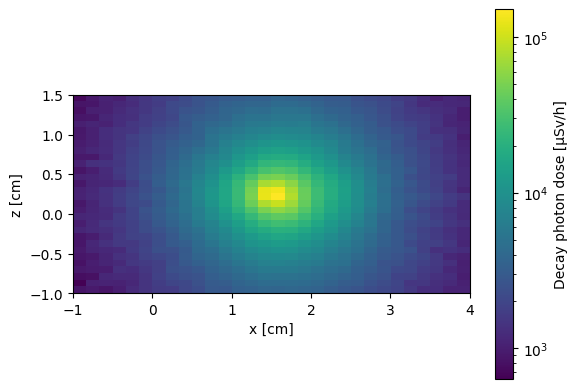

In [19]:
from openmc_regular_mesh_plotter import plot_mesh_tally
with openmc.StatePoint(gamma_sp_filename) as statepoint:
    photon_tally = statepoint.get_tally(name="photon_dose_on_mesh")

    # normalising this tally is a little different to other examples as the source strength has been using units of photons per second.
    # tally.mean is in units of pSv-cm3/source photon.
    # as source strength is in photons_per_second this changes units to pSv-/second

    # multiplication by pico_to_micro converts from (pico) pSv/s to (micro) uSv/s
    # dividing by mesh voxel volume cancles out the cm3 units
    # could do the mesh volume scaling on the plot and vtk functions but doing it here instead
    pico_to_micro = 1e-6
    seconds_to_hours = 60*60
    scaling_factor = (seconds_to_hours * pico_to_micro) / regularmesh.volumes[0][0][0]

    plot = plot_mesh_tally(
            tally=photon_tally,
            basis="xz",
            # score='flux', # only one tally so can make use of default here
            value="mean",
            colorbar_kwargs={
                'label': "Decay photon dose [µSv/h]",
            },
            norm=LogNorm(),
            volume_normalization=False,  # this is done in the scaling_factor
            scaling_factor=scaling_factor,
        )
    plot.figure.savefig(f'shut_down_dose_map_timestep.png')

You may want to increase the resolution of the regularmesh and rerun the simulation

I can also recommend talking a look shutdown dose rate simulations using the D1S

D1S is generally quicker than R2S.

R2S allows the user the possibility of changing the geometry between the neutron and gamma simulation.
This can be useful for doing shutdown dose rate simulations with moving geometry of geometry that has been irradiated in one position then moved for maintenance and is still active.